In [204]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [205]:
df = pd.read_csv("car_evaluation.csv" , header = None)

In [206]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [207]:
df.shape

(1728, 7)

In [208]:
col_names = ['Buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
col_names

['Buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [209]:
df.isnull().sum()

Buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [210]:
col_names = ['Buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

for col in col_names:
    print(df[col].value_counts())

Buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [211]:
X = df.drop(['class'], axis = 1)
Y = df['class']

In [212]:
Y.value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [213]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y , test_size= 0.33 , random_state = 42)

In [214]:
X_train.head()

,Buying,maint,doors,persons,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


In [215]:
X_train.dtypes


Buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
dtype: object

In [216]:
pip install category-encoders

Note: you may need to restart the kernel to use updated packages.


In [217]:
import category_encoders as ce

In [218]:
encoders = ce.OrdinalEncoder(cols=['Buying', 'maint', 'doors','persons',
                                    'lug_boot', 'safety'])


In [219]:
X_train = encoders.fit_transform(X_train)

In [220]:
X_train.head()

,Buying,maint,doors,persons,lug_boot,safety
48,1,1,1,1,1,1
468,2,1,1,2,2,1
155,1,2,1,1,2,2
1721,3,3,2,1,2,2
1208,4,3,3,1,2,2


In [221]:
X_test = encoders.fit_transform(X_test)

In [222]:
X_train.dtypes

Buying      int64
maint       int64
doors       int64
persons     int64
lug_boot    int64
safety      int64
dtype: object

In [223]:
from sklearn.tree import DecisionTreeClassifier

In [224]:
clf_gini = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state = 0)

# citirion - use gini impurity to measure spilt quality 
# max depth =  3 limits tree depth to prevent from overfiting 



In [225]:
## fit the modell


clf_gini.fit(X_train,Y_train )

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [226]:
Y_pred_gini = clf_gini.predict(X_test)

In [227]:
Y_test.head(5)

599     unacc
1201      acc
628     unacc
1498      acc
1263    unacc
Name: class, dtype: object

In [228]:
Y_pred_gini[:5]

array(['unacc', 'unacc', 'unacc', 'acc', 'unacc'], dtype=object)

In [229]:
from sklearn.metrics import accuracy_score
print('model accuracy with gini {0:0.4f}'.format(accuracy_score(Y_test,Y_pred_gini)))

model accuracy with gini 0.5271


In [231]:
# print the scdore of training and testing 

print('Training set score:{:.4f}'.format(clf_gini.score(X_train,Y_train)))

print('testing set score :{:.4f}'.format(clf_gini.score(X_test,Y_test)))

Training set score:0.7865
testing set score :0.5271


In [233]:
X_train.tail()

,Buying,maint,doors,persons,lug_boot,safety
1130,4,4,1,1,1,2
1294,4,3,2,1,3,3
860,2,3,2,1,1,2
1459,3,2,4,3,2,3
1126,4,4,1,1,2,3


In [235]:
Y_train.head()

48      unacc
468     unacc
155     unacc
1721     good
1208    unacc
Name: class, dtype: object

[Text(0.4, 0.875, 'x[5] <= 1.5\ngini = 0.455\nsamples = 1157\nvalue = [255, 49, 813, 40]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 386\nvalue = [0, 0, 386, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 2.5\ngini = 0.577\nsamples = 771\nvalue = [255, 49, 427, 40]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 2.5\ngini = 0.631\nsamples = 525\nvalue = [255.0, 49.0, 181.0, 40.0]'),
 Text(0.2, 0.125, 'gini = 0.496\nsamples = 271\nvalue = [124, 0, 147, 0]'),
 Text(0.6, 0.125, 'gini = 0.654\nsamples = 254\nvalue = [131, 49, 34, 40]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 246\nvalue = [0, 0, 246, 0]')]

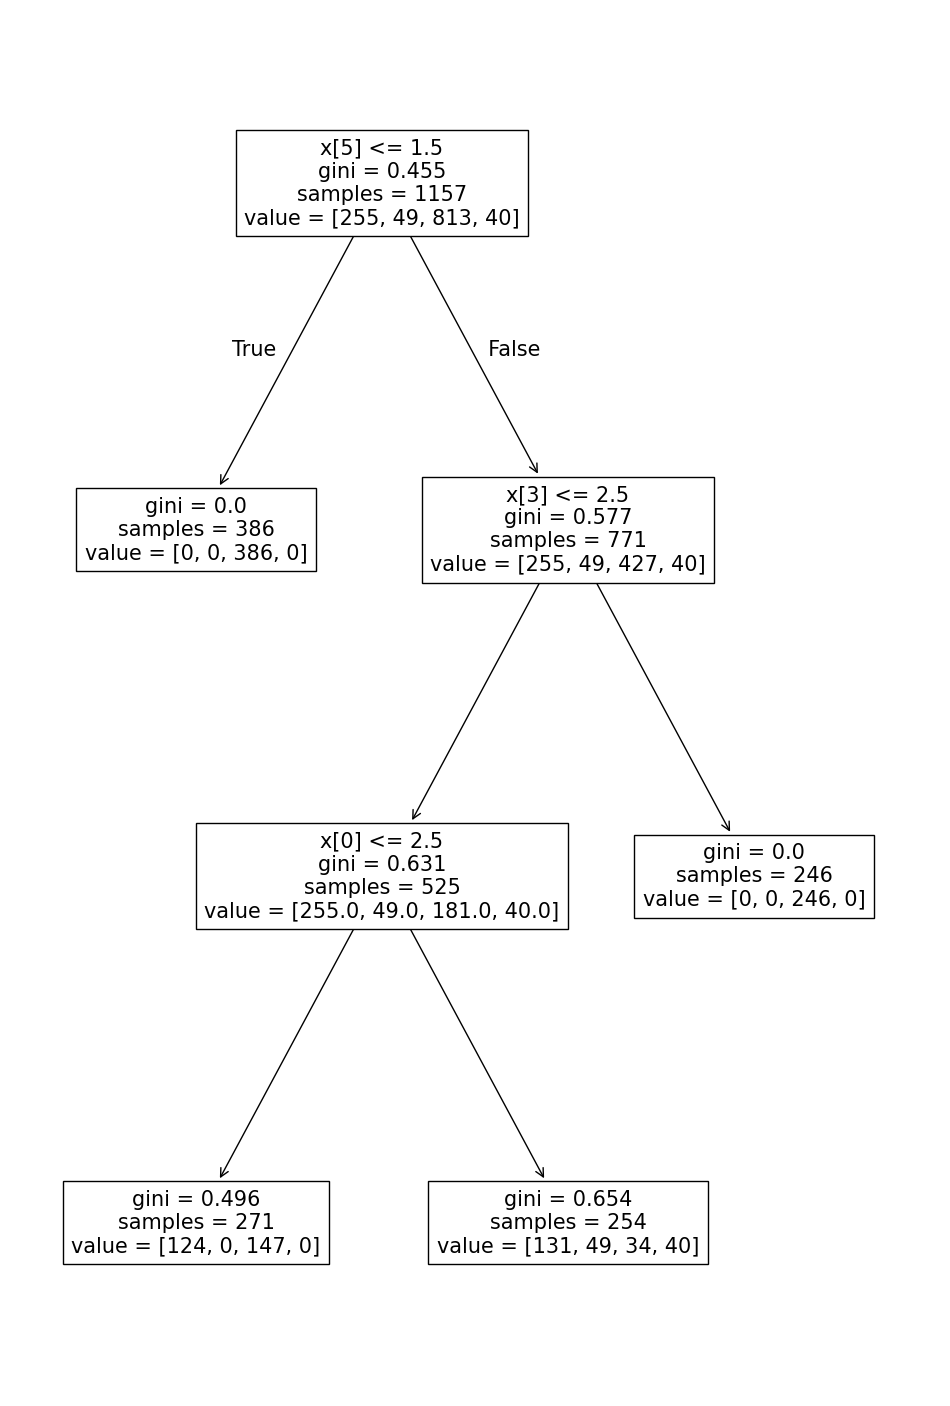

In [236]:
plt.figure(figsize=(12,18))
from sklearn import tree
tree.plot_tree(clf_gini.fit(X_train,Y_train))



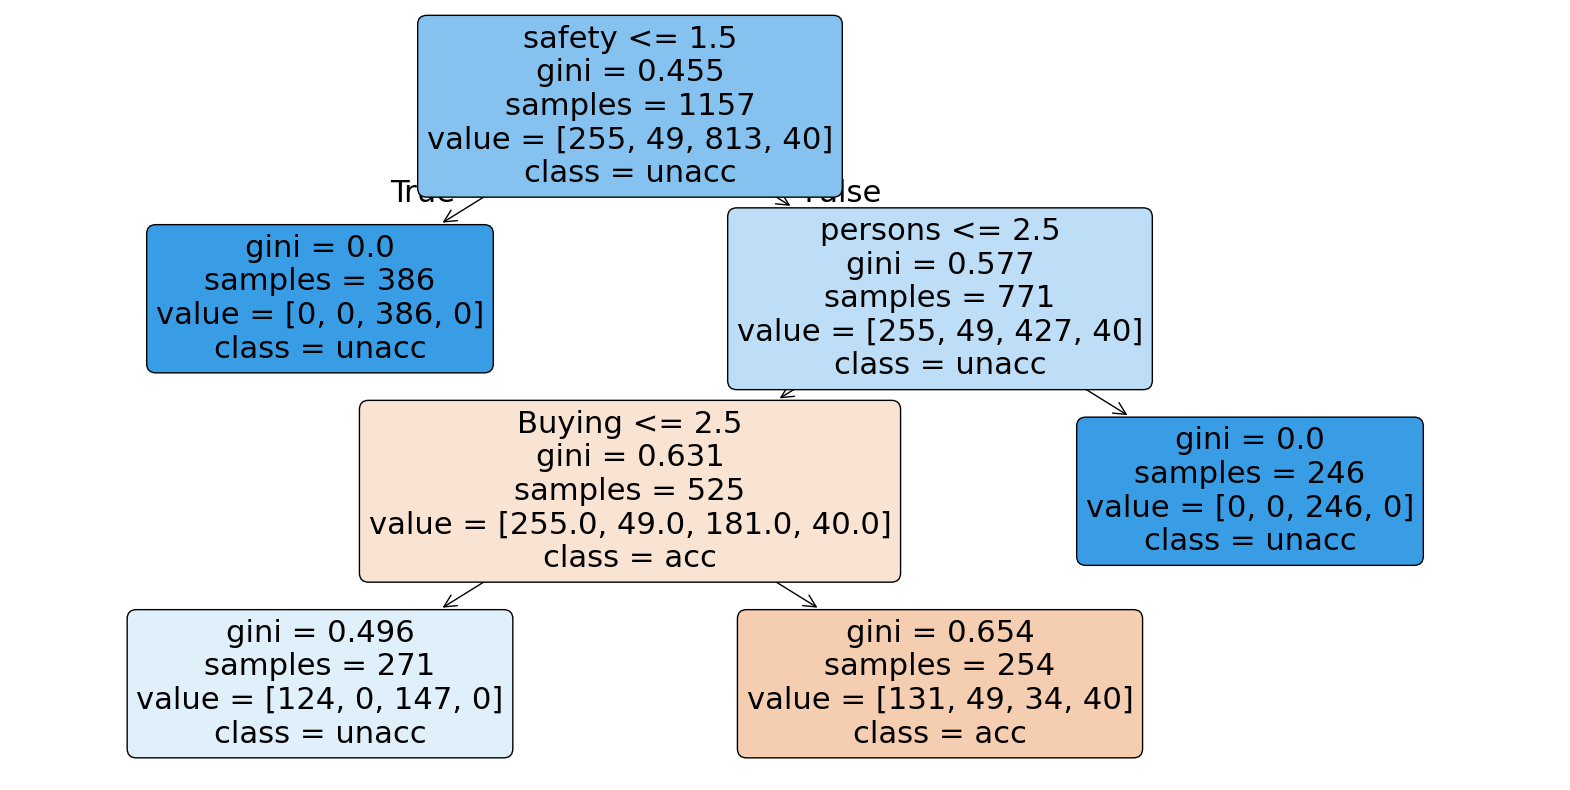

In [240]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf_gini, feature_names =X.columns,class_names = clf_gini.classes_, filled = True, rounded =  True)
plt.show()